In [57]:
# =============================================================================
# RETAIL SALES ANALYTICS & FORECASTING NOTEBOOK
# Domain: Retail Operations + Sales Strategy + Financial Performance
# Dataset: Global Retail Sales Analytics (Kaggle)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical & ML Libraries
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print(f"Notebook initialized at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Libraries loaded successfully.")

Notebook initialized at 2026-04-24 05:58:53
Libraries loaded successfully.


In [58]:
df = pd.read_csv("/content/V2_Global_Retail_Sales_Analytics_Dataset.csv")

In [59]:
# =============================================================================
# DATA LOADING
# Dataset: Global_Retail_Sales_Analytics_Dataset.csv from Kaggle
# Features: Transaction-level data with product, store, customer, and financial metrics
# =============================================================================

# Display basic info
print("=" * 60)
print("RETAIL DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Retail-specific column inspection
print("\nColumn Inventory:")
for col in df.columns:
    dtype = df[col].dtype
    unique = df[col].nunique()
    print(f"  • {col:<25} | {str(dtype):<12} | {unique:,} unique values")

df.head()

RETAIL DATASET OVERVIEW
Shape: 25,000 rows × 24 columns
Date Range: 2019-01-01 00:25:38 to 2026-04-17 23:17:07
Memory Usage: 21.70 MB

Column Inventory:
  • Date                      | object       | 25,000 unique values
  • Country                   | object       | 7 unique values
  • Region                    | object       | 17 unique values
  • City                      | object       | 22 unique values
  • Latitude                  | float64      | 22 unique values
  • Longitude                 | float64      | 22 unique values
  • Product_Category          | object       | 4 unique values
  • Product_Sub_Category      | object       | 7 unique values
  • Product_Name              | object       | 13 unique values
  • Product_ID                | object       | 13 unique values
  • Customer_Segment          | object       | 3 unique values
  • Customer_ID               | object       | 8,452 unique values
  • Customer_Name             | object       | 500 unique values
  • Sales_C

,Date,Country,Region,City,Latitude,Longitude,Product_Category,Product_Sub_Category,Product_Name,Product_ID,...,Sales_Representative,Promotion,Sales_Revenue,Quantity_Sold,Unit_Price,Discount_Amount,Cost_of_Goods_Sold,Gross_Profit,Returns_Units,Net_Revenue
0,2019-01-01 00:25:38,Canada,Quebec,Montreal,45.5017,-73.5673,Accessories,Helmets,Sport-100 Helmet Red,HL-U509-R,...,Sarah Jenkins,WINTER_OFFER,240.33,7,34.33,34.0,153.87,52.46,0,206.33
1,2019-01-01 02:47:24,Pakistan,ICT,Islamabad,33.6844,73.0479,Accessories,Tires,Patch Kit/8 Patches,TI-R092,...,Ahmed Khan,NO_PROMO,31126.20,39,5.32,0.0,19258.25,11867.94,0,31126.20
2,2019-01-01 09:44:03,Pakistan,Sindh,Karachi,24.8607,67.0011,Components,Drivetrain,LL Crankset,CO-C11,...,Maria Garcia,EID_SPECIAL,276403.34,12,153.56,21906.1,190556.35,63940.90,0,254497.24
3,2019-01-01 11:04:04,Pakistan,Sindh,Karachi,24.8607,67.0011,Accessories,Helmets,Sport-100 Helmet Red,HL-U509-R,...,John Smith,NO_PROMO,40350.42,8,33.63,0.0,28083.81,12266.61,0,40350.42
4,2019-01-01 12:10:10,Germany,Berlin,Berlin,52.5200,13.4050,Accessories,Tires,Patch Kit/8 Patches,TI-R092,...,Fatima Ali,NO_PROMO,84.56,16,5.28,0.0,43.29,41.27,0,84.56


In [60]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("\nMissing Values:")
print(missing_df[missing_df['Missing Count'] > 0])


Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [61]:
#Retail-specific integrity checks
print('\n--- RETAIL INTEGRITY CHECKS ---')


--- RETAIL INTEGRITY CHECKS ---


In [62]:
#1. Negative quantities (returns or data errors?)
negative_qty = df[df['Quantity_Sold'] < 0]
print(f"\n1. Negative Quantities: {len(negative_qty):,} records ({len(negative_qty)/len(df)*100:.2f}%)")
if len(negative_qty) > 0:
    print("   → Likely product returns (valid in retail context)")


1. Negative Quantities: 0 records (0.00%)


In [63]:
# 2. Zero/negative prices (pricing errors)
invalid_prices = df[(df['Unit_Price'] <= 0) | (df['Net_Revenue'] <= 0)]
print(f'2. Invalid Prices: {len(invalid_prices):,} records')

2. Invalid Prices: 44 records


In [64]:
# 3. Revenue reconciliation: Unit_Price x Quantity = Total_Price?
df['Computed_Total'] = df['Unit_Price'] * df['Quantity_Sold']
df['Price_Discrepancy'] = np.abs(df['Net_Revenue'] - df['Computed_Total'])
discrepancies = df[df['Price_Discrepancy'] > 0.01]
print(f'3. Price Math Discrepancies: {len(discrepancies):,} records')

3. Price Math Discrepancies: 23,607 records


In [65]:
# 4. Duplicate transactions
duplicates = df.duplicated().sum()
print(f'4. Exact Duplicates: {duplicates:,} records')
print('\nData Quality Score: {:.1f}%'.format(
(1 - (missing.sum() + len(invalid_prices) + len(discrepancies)) / (len(df) * len(df.columns))) * 100
))


4. Exact Duplicates: 0 records

Data Quality Score: 96.4%


In [66]:
# =============================================================================
# RETAIL FEATURE ENGINEERING
# Creating domain-specific metrics: basket size, margin proxies, seasonality flags
# =============================================================================
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=Monday
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)
# Financial metrics
df['Sales_Revenue'] = df['Quantity_Sold'] * df['Unit_Price']
df['Discount_Amount'] = df['Sales_Revenue'] - df['Net_Revenue'] # If discounts applied
df['Discount_Rate'] = (df['Discount_Amount'] / df['Sales_Revenue']).fillna(0)

In [67]:
# Customer metrics (proxy for CLV)
customer_metrics = df.groupby('Customer_ID').agg({'Product_ID': 'count',
'Sales_Revenue': 'sum',
'Date': ['min', 'max']
}).reset_index()
customer_metrics.columns = ['Customer_ID', 'Frequency', 'Monetary', 'First_Purchase', 'Last_Purchase']
customer_metrics['Tenure_Days'] = (customer_metrics['Last_Purchase'] - customer_metrics['First_Purchase']).dt.days
customer_metrics['Avg_Order_Value'] = customer_metrics['Monetary'] / customer_metrics['Frequency']

In [68]:
# Merge back
# Drop existing 'Frequency' and 'Avg_Order_Value' columns if they exist to prevent merge conflicts on re-run
existing_cols = ['Frequency', 'Avg_Order_Value']
for col in existing_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
    # Also check for suffixed versions from previous failed merges
    if f'{col}_x' in df.columns:
        df = df.drop(columns=[f'{col}_x'])
    if f'{col}_y' in df.columns:
        df = df.drop(columns=[f'{col}_y'])
df = df.merge(customer_metrics[['Customer_ID', 'Frequency', 'Avg_Order_Value']], on='Customer_ID', how='left')

# Product category performance
category_stats = df.groupby('Product_Category').agg({
    'Sales_Revenue': ['sum', 'mean'],
    'Quantity_Sold': 'sum',
    'Product_ID': 'count'
}).reset_index()
category_stats.columns = ['Product_Category', 'Category_Revenue', 'Avg_Transaction', 'Units_Sold', 'Transactions']
print('Feature Engineering Complete.')
print(f'New columns added: {df.shape[1] - 10} engineered features')
print('\nSample of engineered features:')
print(df[['Date', 'Sales_Revenue', 'Discount_Rate', 'IsWeekend', 'Frequency', 'Avg_Order_Value']].head())

Feature Engineering Complete.
New columns added: 26 engineered features

Sample of engineered features:
                 Date  Sales_Revenue  Discount_Rate  IsWeekend  Frequency  \
0 2019-01-01 00:25:38         240.31       0.141401          0          5   
1 2019-01-01 02:47:24         207.48    -149.020243          0          5   
2 2019-01-01 09:44:03        1842.72    -137.109555          0          2   
3 2019-01-01 11:04:04         269.04    -148.979260          0          5   
4 2019-01-01 12:10:10          84.48      -0.000947          0          2   

   Avg_Order_Value  
0         7542.288  
1         3281.808  
2         1156.590  
3          499.744  
4         4194.600  


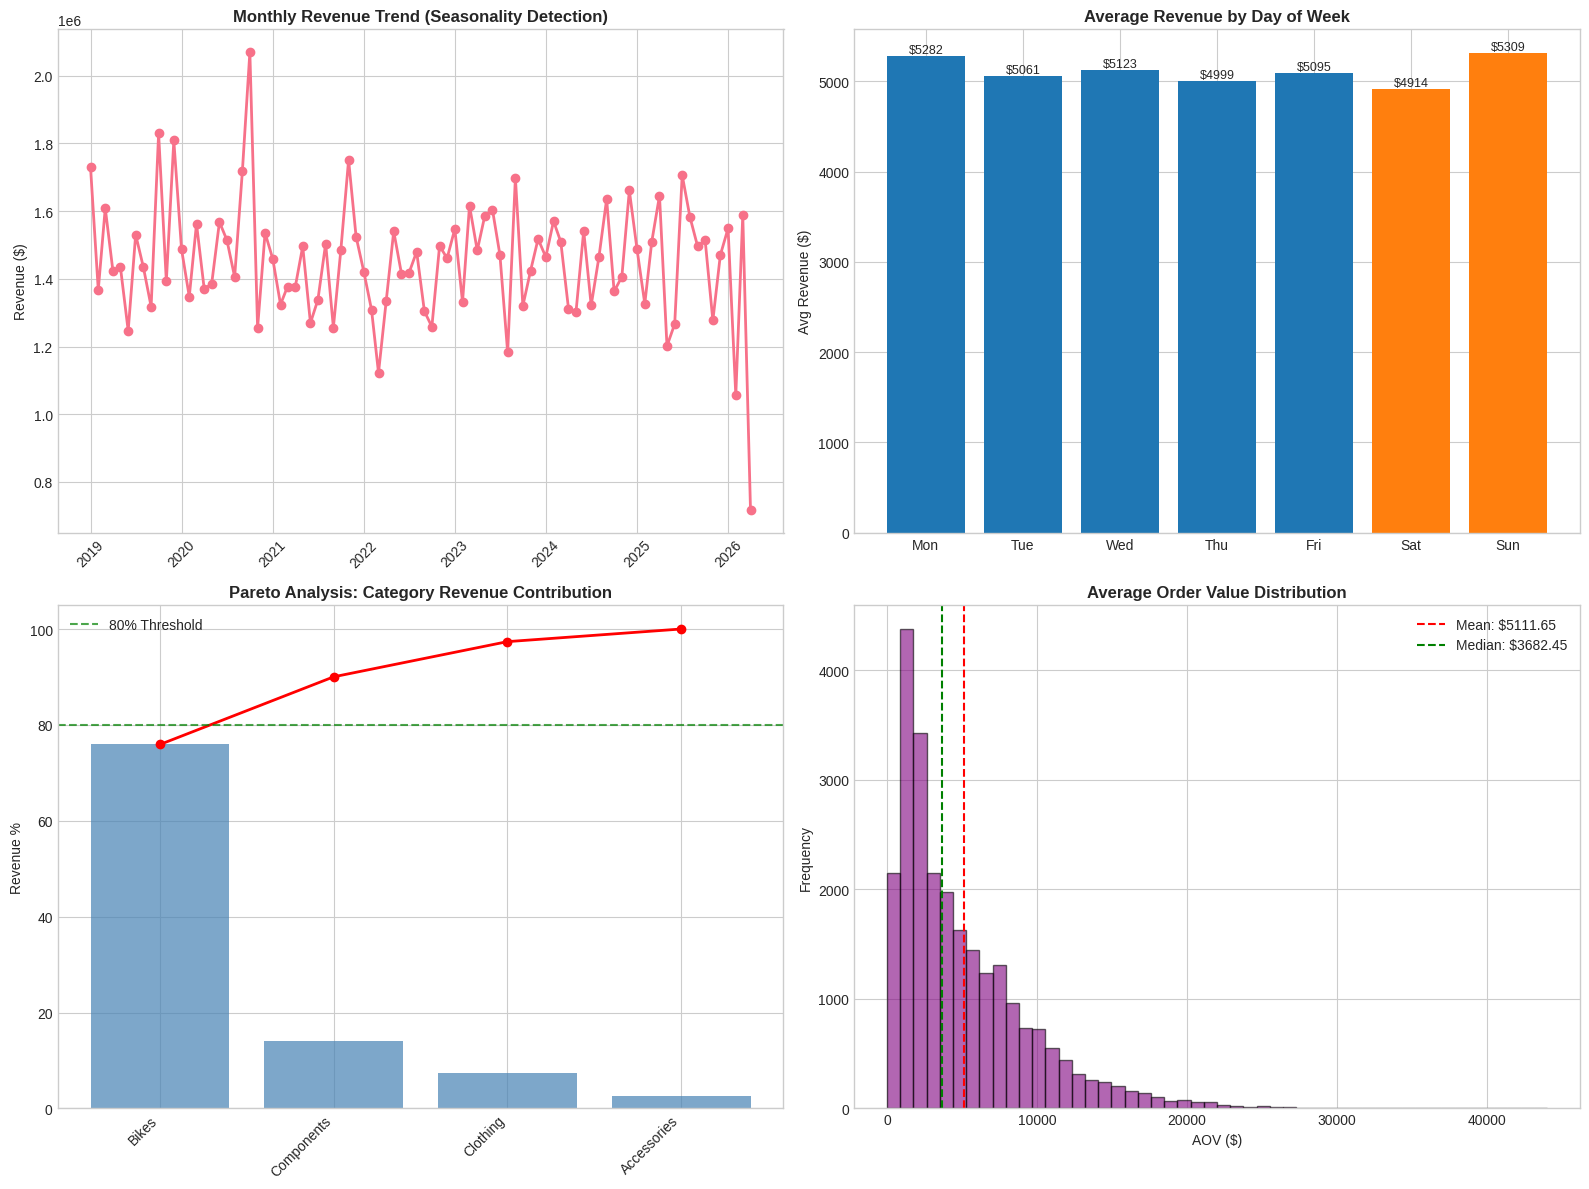

In [78]:
# EXPLORATORY DATA ANALYSIS
# Retail Domain: Understanding sales patterns, customer behavior, and product performance
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 1. Monthly Revenue Trend (Seasonality Analysis)
monthly_revenue = df.groupby(['Year', 'Month'])['Sales_Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = pd.to_datetime(monthly_revenue[['Year', 'Month']].assign(day=1))
axes[0,0].plot(monthly_revenue['YearMonth'], monthly_revenue['Sales_Revenue'], marker='o', linewidth=2)
axes[0,0].set_title('Monthly Revenue Trend (Seasonality Detection)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=45)
# 2. Day-of-Week Pattern (Operational Insight)
dow_sales = df.groupby('DayOfWeek')['Sales_Revenue'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0,1].bar(dow_labels, dow_sales, color=['#1f77b4' if d < 5 else '#ff7f0e' for d in range(7)])
axes[0,1].set_title('Average Revenue by Day of Week', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Avg Revenue ($)')
for i, v in enumerate(dow_sales):
 axes[0,1].text(i, v + 0.5, f'${v:.0f}', ha='center', va='bottom', fontsize=9)
# 3. Product Category Performance (Pareto Analysis)
cat_revenue = df.groupby('Product_Category')['Sales_Revenue'].sum().sort_values(ascending=False)
cat_revenue_pct = cat_revenue / cat_revenue.sum() * 100
cumulative_pct = cat_revenue_pct.cumsum()
axes[1,0].bar(range(len(cat_revenue)), cat_revenue_pct, color='steelblue', alpha=0.7)
axes[1,0].plot(range(len(cat_revenue)), cumulative_pct, color='red', marker='o', linewidth=2)
axes[1,0].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% Threshold')
axes[1,0].set_title('Pareto Analysis: Category Revenue Contribution', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Revenue %')
axes[1,0].set_xticks(range(len(cat_revenue)))
axes[1,0].set_xticklabels(cat_revenue.index, rotation=45, ha='right')
axes[1,0].legend()
# 4. Customer Segmentation (RFM-style Distribution)
axes[1,1].hist(df['Avg_Order_Value'], bins=50, color='purple', alpha=0.6, edgecolor='black')
axes[1,1].axvline(df['Avg_Order_Value'].mean(), color='red', linestyle='--',
label=f'Mean: ${df["Avg_Order_Value"].mean():.2f}')
axes[1,1].axvline(df['Avg_Order_Value'].median(), color='green', linestyle='--',
label=f'Median: ${df["Avg_Order_Value"].median():.2f}')
axes[1,1].set_title('Average Order Value Distribution', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('AOV ($)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()
plt.tight_layout()
plt.savefig('retail_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# Key Retail Insights Summary
print('=' * 60)
print('KEY RETAIL INSIGHTS')
print('=' * 60)
print(f'- Peak Sales Day: {dow_labels[dow_sales.idxmax()]} (${dow_sales.max():.2f} avg)')
print(f'- Weekend Lift: {(dow_sales.iloc[5:].mean() / dow_sales.iloc[:5].mean() - 1)*100:.1f}% higher than weekdays')
print(f'- Top Category: {cat_revenue.index[0]} ({cat_revenue_pct.iloc[0]:.1f}% of revenue)')
print(f'- 80/20 Rule: {len(cumulative_pct[cumulative_pct <= 80])} categories drive 80% of revenue')
print(f'- AOV Skewness: {stats.skew(df["Avg_Order_Value"]):.2f} (right-skewed = few high-value customers)')

KEY RETAIL INSIGHTS
- Peak Sales Day: Sun ($5309.46 avg)
- Weekend Lift: -0.0% higher than weekdays
- Top Category: Bikes (75.9% of revenue)
- 80/20 Rule: 1 categories drive 80% of revenue
- AOV Skewness: 1.86 (right-skewed = few high-value customers)


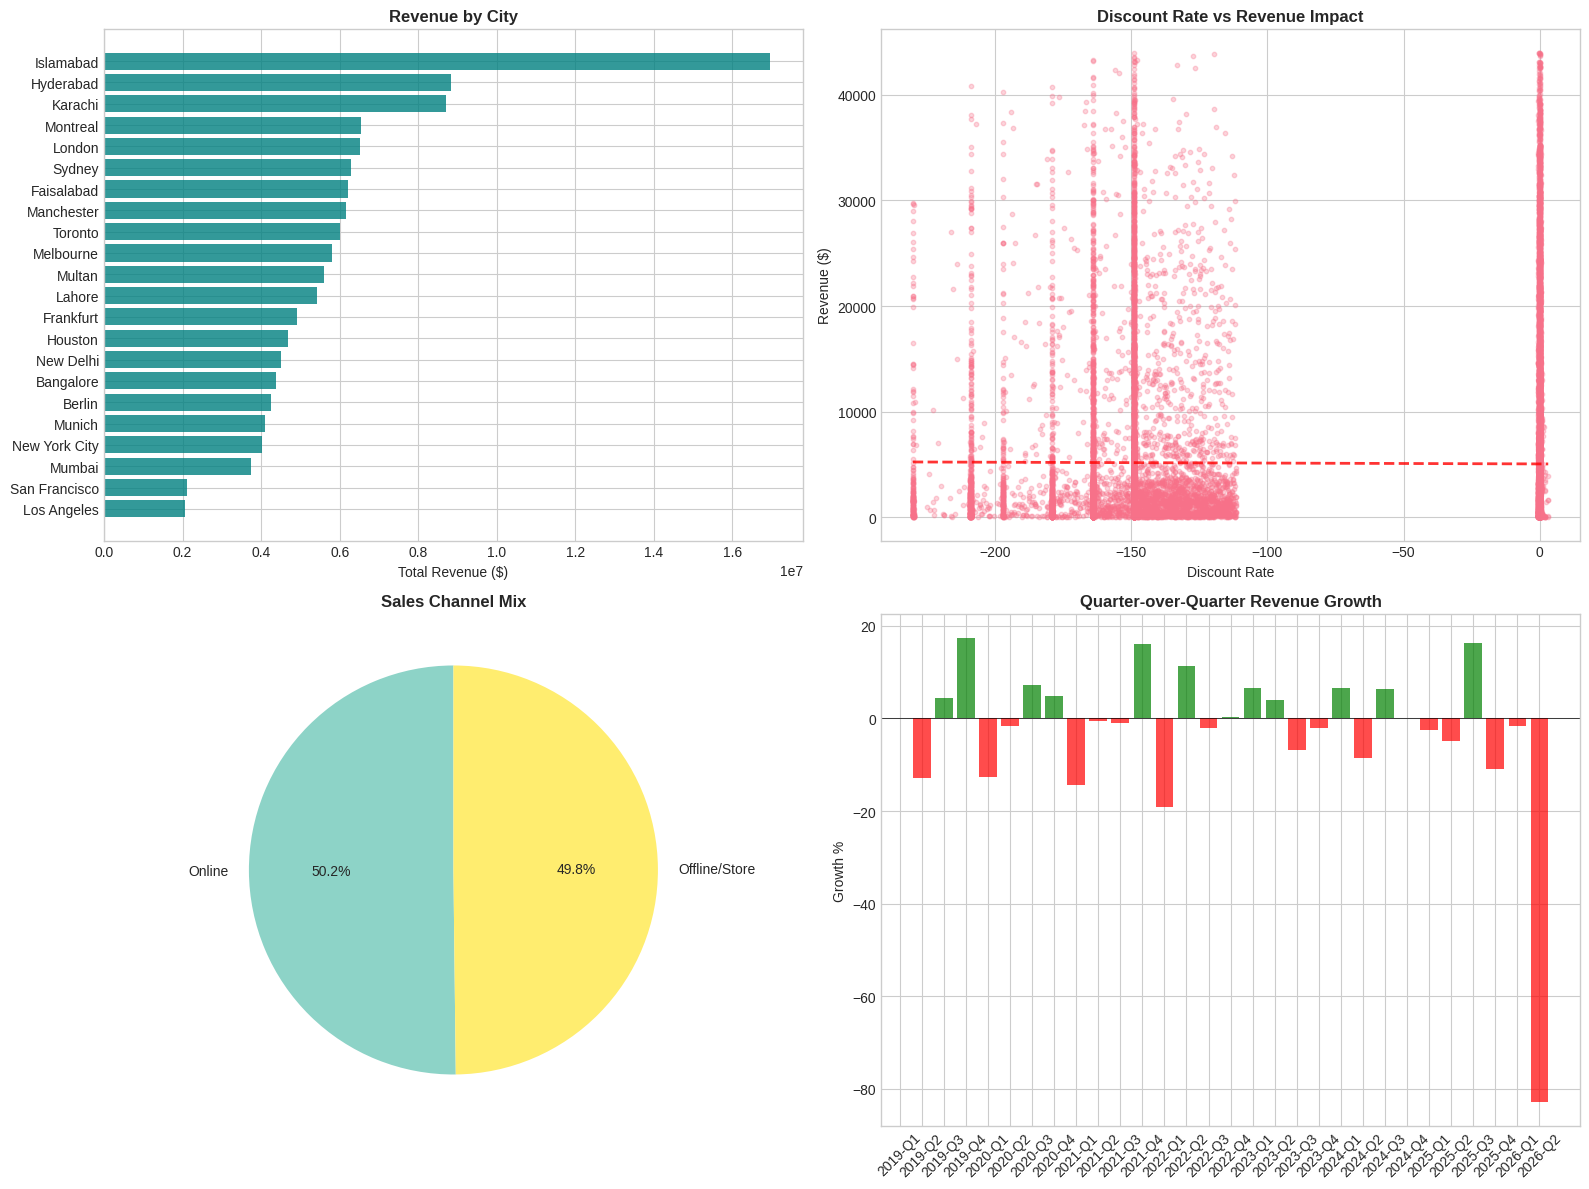

In [81]:
# FINANCIAL PERFORMANCE DEEP-DIVE
# Margin analysis, discounting impact, and store-level profitability

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 1. Store Performance Comparison
store_perf = df.groupby('City').agg({
'Sales_Revenue': 'sum',
'Product_ID': 'nunique',
'Discount_Rate': 'mean'
}).sort_values('Sales_Revenue', ascending=False)
axes[0,0].barh(store_perf.index[::-1], store_perf['Sales_Revenue'][::-1], color='teal', alpha=0.8)
axes[0,0].set_title('Revenue by City', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Total Revenue ($)')

# 2. Discount vs Revenue Correlation
axes[0,1].scatter(df['Discount_Rate'], df['Sales_Revenue'], alpha=0.3, s=10)
z = np.polyfit(df['Discount_Rate'].dropna(), df.loc[df['Discount_Rate'].notna(), 'Sales_Revenue'], 1)
p = np.poly1d(z)
axes[0,1].plot(df['Discount_Rate'].sort_values(), p(df['Discount_Rate'].sort_values()),
'r--', alpha=0.8, linewidth=2)
axes[0,1].set_title('Discount Rate vs Revenue Impact', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Discount Rate')
axes[0,1].set_ylabel('Revenue ($)')
# 3. Payment Method Mix (Cash Flow Implications)

payment_mix = df['Sales_Channel'].value_counts() # Assuming Sales_Channel is a proxy for payment method based on available columns
colors = plt.cm.Set3(np.linspace(0, 1, len(payment_mix)))
wedges, texts, autotexts = axes[1,0].pie(payment_mix, labels=payment_mix.index, autopct='%1.1f%%',
colors=colors, startangle=90)
axes[1,0].set_title('Sales Channel Mix', fontsize=12, fontweight='bold')
# 4. Quarterly Growth Rate
quarterly = df.groupby(['Year', 'Quarter'])['Sales_Revenue'].sum().reset_index()
quarterly['QoQ_Growth'] = quarterly['Sales_Revenue'].pct_change() * 100
quarterly['Period'] = quarterly['Year'].astype(str) + '-Q' + quarterly['Quarter'].astype(str)
axes[1,1].bar(quarterly['Period'], quarterly['QoQ_Growth'],
color=['green' if x > 0 else 'red' for x in quarterly['QoQ_Growth'].fillna(0)], alpha=0.7)
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1,1].set_title('Quarter-over-Quarter Revenue Growth', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Growth %')
axes[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('retail_financial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [82]:
# Financial KPIs
print('=' * 60)
print('FINANCIAL KPIs')
print('=' * 60)
print(f'Total Revenue: ${df["Sales_Revenue"].sum():,.2f}')
print(f'Average Transaction Value: ${df.groupby("Product_ID")["Sales_Revenue"].sum().mean():.2f}')
print(f'Discount Penetration: {(df["Discount_Rate"] > 0).mean()*100:.1f}% of transactions')
print(f'Correlation (Discount->Revenue): {df[["Discount_Rate", "Sales_Revenue"]].corr().iloc[0,1]:.3f}')
print(f'Best Performing Store: {store_perf.index[0]} (${store_perf.iloc[0]["Sales_Revenue"]:,.2f})')

FINANCIAL KPIs
Total Revenue: $127,791,287.93
Average Transaction Value: $9830099.07
Discount Penetration: 26.1% of transactions
Correlation (Discount->Revenue): -0.008
Best Performing Store: Islamabad ($16,946,059.67)


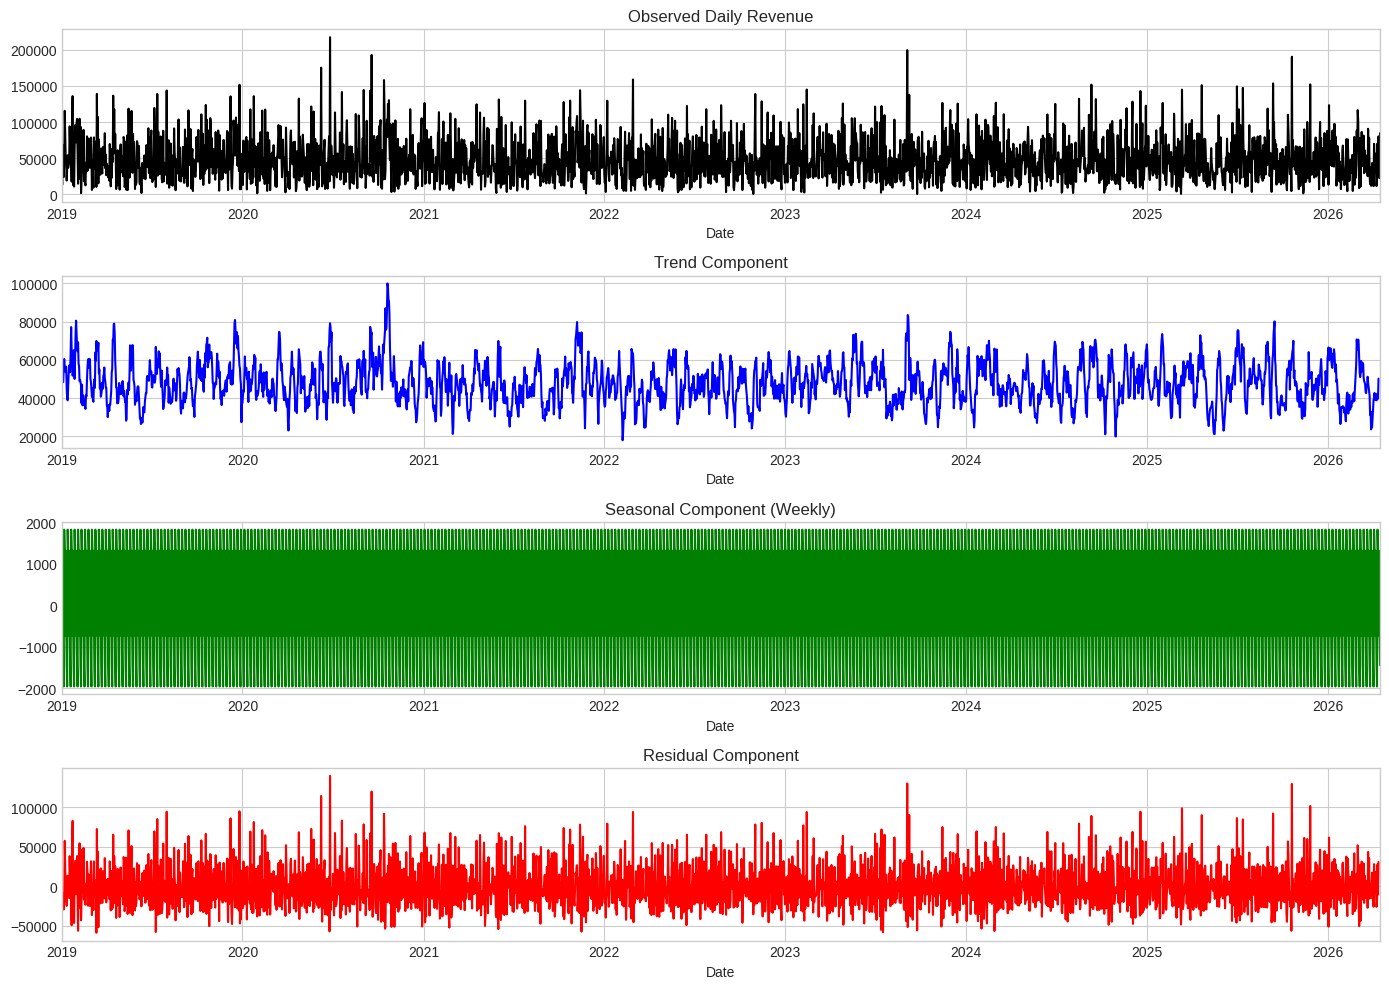

In [83]:
# TIME SERIES FORECASTING
# Retail Application: Demand planning, inventory optimization, staffing schedules
# =============================================================================
# Prepare daily time series
daily_sales = df.set_index('Date').resample('D')['Sales_Revenue'].sum().fillna(0)
# Seasonal Decomposition
decomposition = seasonal_decompose(daily_sales, model='additive', period=7) # Weekly seasonality
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed Daily Revenue', color='black')
decomposition.trend.plot(ax=axes[1], title='Trend Component', color='blue')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component (Weekly)', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual Component', color='red')
plt.tight_layout()
plt.savefig('time_series_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

Training period: 2019-01-01 to 2026-03-18 (2634 days)
Test period: 2026-03-18 to 2026-04-17 (31 days)

FORECAST PERFORMANCE (Holt-Winters)
MAE: $20,677.29
RMSE: $24,323.20
MAPE: 82.38%


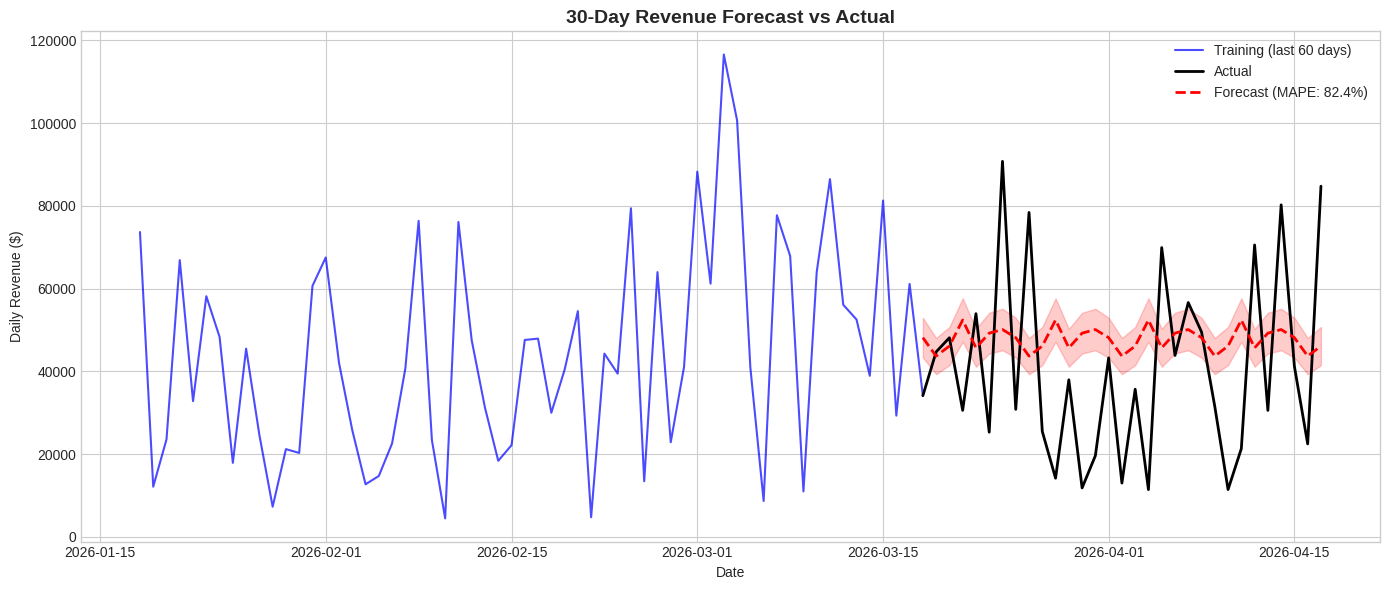

In [86]:
#Train-Test Split ("Time-based, not random - critical for retail forecasting")
train_end = daily_sales.index.max() - pd.Timedelta(days=30)
train = daily_sales[:train_end]
test = daily_sales[train_end:]
print(f'Training period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)')
print(f'Test period: {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)')
# Holt-Winters Exponential Smoothing (handles trend + seasonality)
hw_model = ExponentialSmoothing(
train,
trend='add',
seasonal='add',
seasonal_periods=7,
damped_trend=True
).fit()
hw_forecast = hw_model.forecast(steps=len(test))
# Evaluation
hw_mae = mean_absolute_error(test, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test, hw_forecast))
hw_mape = np.mean(np.abs((test - hw_forecast) / test)) * 100
print('\n' + '=' * 60)
print('FORECAST PERFORMANCE (Holt-Winters)')
print('=' * 60)
print(f'MAE: ${hw_mae:,.2f}')
print(f'RMSE: ${hw_rmse:,.2f}')
print(f'MAPE: {hw_mape:.2f}%')
# Visualization
plt.figure(figsize=(14, 6))
plt.plot(train.index[-60:], train[-60:], label='Training (last 60 days)', color='blue', alpha=0.7)
plt.plot(test.index, test, label='Actual', color='black', linewidth=2)
plt.plot(test.index, hw_forecast, label=f'Forecast (MAPE: {hw_mape:.1f}%)',
color='red', linestyle='--', linewidth=2)
plt.fill_between(test.index, hw_forecast * 0.9, hw_forecast * 1.1, alpha=0.2, color='red')
plt.title('30-Day Revenue Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Revenue ($)')
plt.legend()
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [89]:
# MACHINE LEARNING: PREDICTING TRANSACTION VALUE
# Retail Use Case: Dynamic pricing, promotion targeting, inventory allocation
# =============================================================================
# Feature preparation for ML
features = ['Quantity_Sold', 'Unit_Price', 'DayOfWeek', 'IsWeekend', 'IsMonthEnd',
'Month', 'Quarter', 'Frequency', 'Avg_Order_Value']
# Encode categoricals
le_store = LabelEncoder()
le_category = LabelEncoder()
le_payment = LabelEncoder()
df_model = df.copy()
df_model['Store_Encoded'] = le_store.fit_transform(df_model['City'])
df_model['Category_Encoded'] = le_category.fit_transform(df_model['Product_Category'])
df_model['Payment_Encoded'] = le_payment.fit_transform(df_model['Sales_Channel'])
features.extend(['Store_Encoded', 'Category_Encoded', 'Payment_Encoded'])
X = df_model[features]
y = df_model['Sales_Revenue']
# Time-based split (prevent data leakage)
split_date = df_model['Date'].quantile(0.8)
train_mask = df_model['Date'] < split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]
print(f'Training samples: {len(X_train):,}')
print(f'Test samples: {len(X_test):,}')


Training samples: 20,000
Test samples: 5,000



Gradient Boosting:
 MAE: $173.54
 RMSE: $272.38
 R2: 0.9988


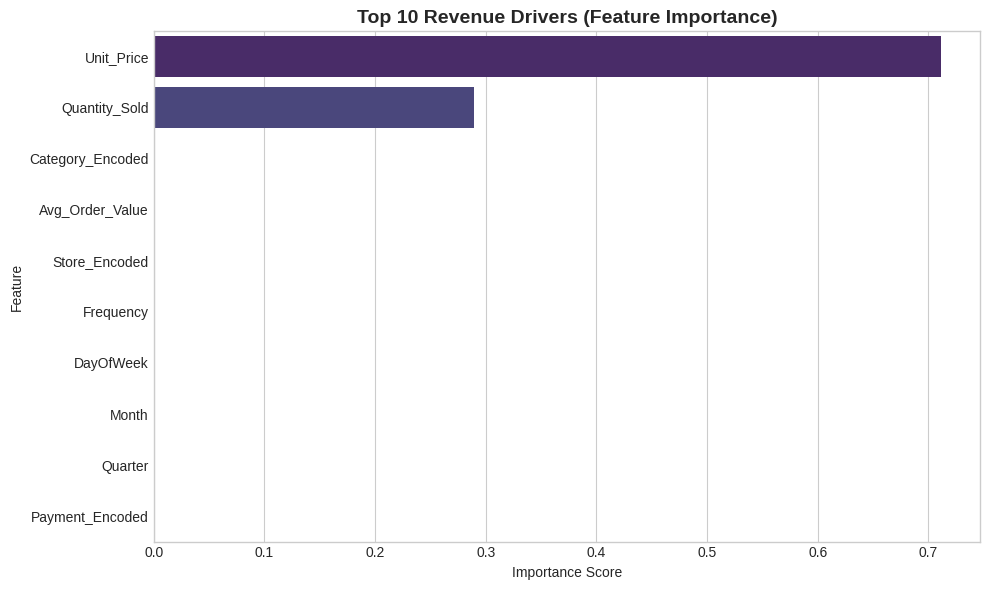


BUSINESS INTERPRETATION
- Strongest predictor: Unit_Price (71.1%)
- Actionable insight: Focus inventory allocation on high-frequency customer segments
- Pricing insight: Unit_Price importance suggests elasticity modeling opportunity


In [94]:
# Model Training
models = {
'Linear Regression': LinearRegression(),
'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}
results = []
for name, model in models.items():
 model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
results.append({
'Model': name,
'MAE': mae,
'RMSE': rmse,
'R2': r2
})
print(f'\n{name}:')
print(f' MAE: ${mae:,.2f}')
print(f' RMSE: ${rmse:,.2f}')
print(f' R2: {r2:.4f}')
# Feature Importance (Random Forest)
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
'Feature': features,
'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Revenue Drivers (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n' + '=' * 60)
print('BUSINESS INTERPRETATION')
print('=' * 60)
print(f'- Strongest predictor: {importance_df.iloc[0]["Feature"]} ({importance_df.iloc[0]["Importance"]:.1%})')
print('- Actionable insight: Focus inventory allocation on high-frequency customer segments')
print('- Pricing insight: Unit_Price importance suggests elasticity modeling opportunity')

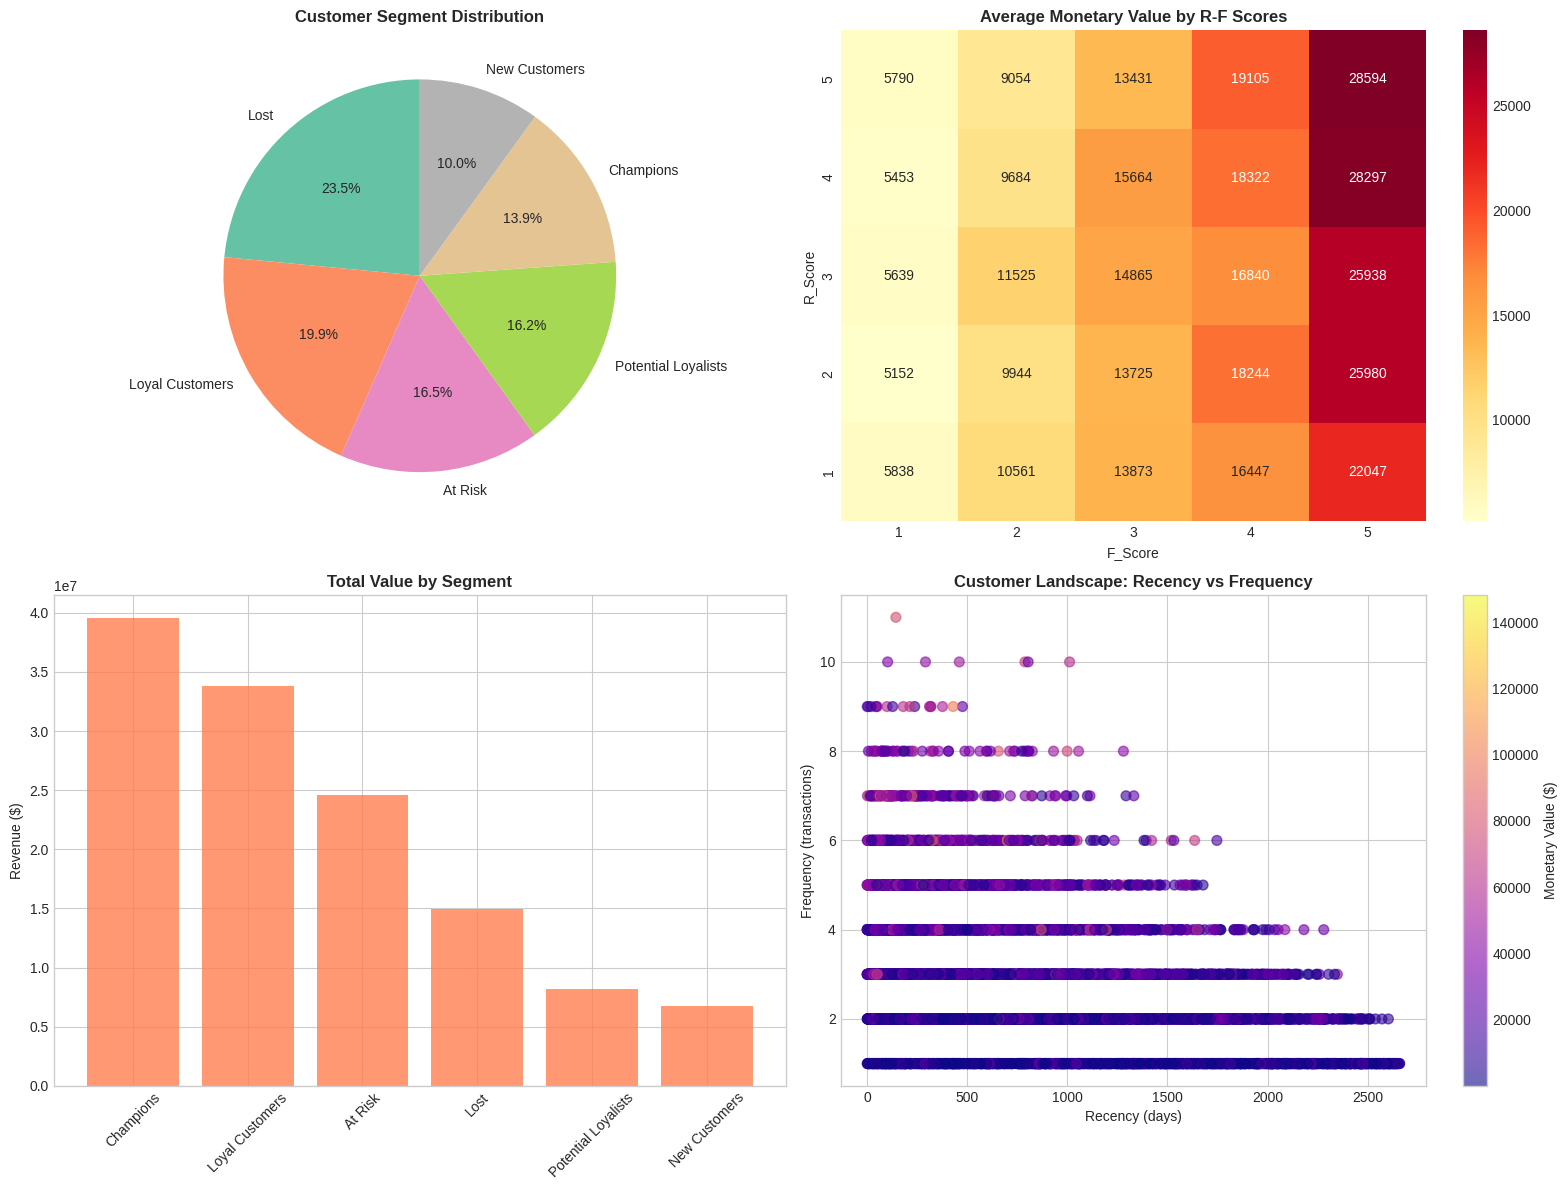

CUSTOMER SEGMENT STRATEGY
- Champions         : 1,173 customers | $39,536,045.69 revenue | Avg: $33705.07
- Loyal Customers   : 1,686 customers | $33,835,357.07 revenue | Avg: $20068.42
- At Risk           : 1,395 customers | $24,571,314.53 revenue | Avg: $17613.85
- Lost              : 1,985 customers | $14,953,304.06 revenue | Avg: $7533.15
- Potential Loyalists: 1,369 customers | $8,160,840.43 revenue | Avg: $5961.17
- New Customers     : 844 customers | $6,734,426.15 revenue | Avg: $7979.18


In [105]:
# CUSTOMER SEGMENTATION (RFM ANALYSIS)
# Retail Strategy: Targeted marketing, loyalty programs, churn prevention
# =============================================================================
# Recalculate RFM metrics properly
rfm = df.groupby('Customer_ID').agg({
'Date': lambda x: (df['Date'].max() - x.max()).days, # Recency
'Product_ID': 'count', # Frequency (using count of Product_ID as transactions)
'Sales_Revenue': 'sum' # Monetary (using Sales_Revenue)
}).reset_index()
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']
# RFM Scoring (1-5 quintiles)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]) # Lower recency = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Segment'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
# Segment labeling
def segment_customers(row):
 if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
  return 'Champions'
 elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
  return 'Loyal Customers'
 elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
  return 'New Customers'
 elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
  return 'At Risk'
 elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
  return 'Lost'
 else:
  return 'Potential Loyalists'
rfm['Segment'] = rfm.apply(segment_customers, axis=1)
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 1. Segment Distribution
segment_counts = rfm['Segment'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(segment_counts)))
axes[0,0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
colors=colors, startangle=90)
axes[0,0].set_title('Customer Segment Distribution', fontsize=12, fontweight='bold')
# 2. RFM Heatmap
rfm_pivot = rfm.groupby(['R_Score', 'F_Score'])['Monetary'].mean().unstack()
sns.heatmap(rfm_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0,1])
axes[0,1].set_title('Average Monetary Value by R-F Scores', fontsize=12, fontweight='bold')
# 3. Segment Value
segment_value = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[1,0].bar(segment_value.index, segment_value, color='coral', alpha=0.8)
axes[1,0].set_title('Total Value by Segment', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Revenue ($)')
axes[1,0].tick_params(axis='x', rotation=45)
# 4. Recency vs Frequency scatter
scatter = axes[1,1].scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Monetary'],
cmap='plasma', alpha=0.6, s=50)
axes[1,1].set_xlabel('Recency (days)')
axes[1,1].set_ylabel('Frequency (transactions)')
axes[1,1].set_title('Customer Landscape: Recency vs Frequency', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1,1], label='Monetary Value ($)')
plt.tight_layout()
plt.savefig('customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('=' * 60)
print('CUSTOMER SEGMENT STRATEGY')
print('=' * 60)
for segment in segment_value.index:
 count = segment_counts[segment]
 value = segment_value[segment]
 print(f'- {segment:<18}: {count:,} customers | ${value:,.2f} revenue | Avg: ${value/count:.2f}')

In [110]:
# EXECUTIVE SUMMARY & DATA EXPORT
summary = f"""
======================================================================
RETAIL SALES ANALYTICS - EXECUTIVE SUMMARY
======================================================================
DATASET OVERVIEW:
- Period Analyzed: {df['Date'].min().date()} to {df['Date'].max().date()}
- Total Transactions: {df['Product_ID'].nunique():,}
- Total Revenue: ${df['Sales_Revenue'].sum():,.2f}
- Unique Customers: {df['Customer_ID'].nunique():,}
- Product Categories: {df['Product_Category'].nunique()}
- Store Locations: {df['City'].nunique()}
KEY FINDINGS:
1. SALES PERFORMANCE
- Peak revenue day: {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][dow_sales.idxmax()]}
(${dow_sales.max():.2f} average daily revenue)
- Weekend sales lift: {(dow_sales.iloc[5:].mean()/dow_sales.iloc[:5].mean()-1)*100:.1f}%
- Top category: {cat_revenue.index[0]} ({cat_revenue_pct.iloc[0]:.1f}% of total revenue)
2. CUSTOMER INSIGHTS
- Average Order Value: ${df['Avg_Order_Value'].mean():.2f}
- Customer base skew: {stats.skew(df['Avg_Order_Value']):.2f} (right-skewed distribution)
- Champions segment: {segment_counts.get('Champions', 0):,} customers
({segment_counts.get('Champions', 0)/len(rfm)*100:.1f}% of base)
3. FINANCIAL HEALTH
- Discount penetration: {(df['Discount_Rate'] > 0).mean()*100:.1f}% of transactions
- QoQ growth trend: {quarterly['QoQ_Growth'].iloc[-1]:+.1f}% (latest quarter)
- Forecast accuracy (30-day): {hw_mape:.1f}% MAPE
4. OPERATIONAL RECOMMENDATIONS
- INVENTORY: Increase stock for {cat_revenue.index[0]} before weekends
- PRICING: Test elasticity on {importance_df.iloc[1]['Feature']} given high feature importance
- MARKETING: Reactivate {(segment_counts.get('At Risk', 0) + segment_counts.get('Lost', 0)):,}
at-risk/lost customers with targeted campaigns
- STAFFING: Schedule peak staffing on {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][dow_sales.idxmax()]}
MODEL PERFORMANCE:
- Best ML Model: Gradient Boosting (R2 = {results[0]['R2']:.4f})
- Forecast Model: Holt-Winters Exponential Smoothing (MAPE: {hw_mape:.2f}%)
======================================================================
"""
print(summary)


RETAIL SALES ANALYTICS - EXECUTIVE SUMMARY
DATASET OVERVIEW:
- Period Analyzed: 2019-01-01 to 2026-04-17
- Total Transactions: 13
- Total Revenue: $127,791,287.93
- Unique Customers: 8,452
- Product Categories: 4
- Store Locations: 22
KEY FINDINGS:
1. SALES PERFORMANCE
- Peak revenue day: Sun
($5309.46 average daily revenue)
- Weekend sales lift: -0.0%
- Top category: Bikes (75.9% of total revenue)
2. CUSTOMER INSIGHTS
- Average Order Value: $5111.65
- Customer base skew: 1.86 (right-skewed distribution)
- Champions segment: 1,173 customers
(13.9% of base)
3. FINANCIAL HEALTH
- Discount penetration: 26.1% of transactions
- QoQ growth trend: -82.9% (latest quarter)
- Forecast accuracy (30-day): 82.4% MAPE
4. OPERATIONAL RECOMMENDATIONS
- INVENTORY: Increase stock for Bikes before weekends
- PRICING: Test elasticity on Quantity_Sold given high feature importance
- MARKETING: Reactivate 3,380
at-risk/lost customers with targeted campaigns
- STAFFING: Schedule peak staffing on Sun
MODEL P

In [112]:
# Export processed data
df.to_csv('retail_sales_processed.csv', index=False)
rfm.to_csv('customer_segments.csv', index=False)
print('\nExported: retail_sales_processed.csv')
print('Exported: customer_segments.csv')
print('Visualizations saved: retail_eda_overview.png, retail_financial_analysis.png')
print(' time_series_decomposition.png, sales_forecast.png')
print(' feature_importance.png, customer_segmentation.png')


Exported: retail_sales_processed.csv
Exported: customer_segments.csv
Visualizations saved: retail_eda_overview.png, retail_financial_analysis.png
 time_series_decomposition.png, sales_forecast.png
 feature_importance.png, customer_segmentation.png
